In [0]:
#0. Environment Setup
import sys

try:
    spark  # already defined by the Databricks runtime
    RUNNING_IN_DATABRICKS = True
except NameError:
    RUNNING_IN_DATABRICKS = False
    from pyspark.sql import SparkSession
    from delta import configure_spark_with_delta_pip

    builder = (
        SparkSession.builder.appName("CrossSystemDataDriftTrustPlatform")
        .master("local[*]")
        .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
        .config("spark.sql.catalog.spark_catalog",
                "org.apache.spark.sql.delta.catalog.DeltaCatalog")
        .config("spark.sql.warehouse.dir", "/home/claude/project/spark-warehouse")
        .config("spark.ui.showConsoleProgress", "false")
    )
    spark = configure_spark_with_delta_pip(builder).getOrCreate()
    spark.sparkContext.setLogLevel("ERROR")

print("Spark version:", spark.version, "| Running in Databricks:", RUNNING_IN_DATABRICKS)


Spark version: 4.1.0 | Running in Databricks: True


In [0]:
# 2. Configuration
import os

if RUNNING_IN_DATABRICKS:
    dbutils.widgets.text("catalog", "workspace", "Unity Catalog name")
    dbutils.widgets.text("schema", "default", "Schema name")
    dbutils.widgets.text("volume", "project_data", "Volume name")
    CATALOG = dbutils.widgets.get("catalog")
    SCHEMA = dbutils.widgets.get("schema")
    VOLUME = dbutils.widgets.get("volume")
    BASE_PATH = f"/Volumes/{CATALOG}/{SCHEMA}/{VOLUME}"
else:
    BASE_PATH = "/home/claude/project/project_data"

PATHS = {
    "crm":       {"current": f"{BASE_PATH}/current/crm_dataset.csv",
                  "baseline": f"{BASE_PATH}/baseline/crm_dataset.csv"},
    "billing":   {"current": f"{BASE_PATH}/current/billing_dataset.csv",
                  "baseline": f"{BASE_PATH}/baseline/billing_dataset.csv"},
    "analytics": {"current": f"{BASE_PATH}/current/analytics_dataset.csv",
                  "baseline": f"{BASE_PATH}/baseline/analytics_dataset.csv"},
}
STREAMING_SOURCE = f"{BASE_PATH}/streaming_events"


THRESHOLDS = {
    "volume_drift_pct":        0.15,   # flag if record count changes by more than 15%
    "distribution_drift_psi":  0.10,   # PSI > 0.10 = moderate drift, > 0.25 = severe
    "aggregation_mismatch_tol": 0.02,  # 2% tolerance between Billing and Analytics totals
    "trust_score_warn":        75.0,   # trust score below this -> WARNING alert
    "trust_score_critical":    50.0,   # trust score below this -> CRITICAL alert
}

print("Base path:", BASE_PATH)
print("Thresholds:", THRESHOLDS)


Base path: /Volumes/workspace/default/project_data
Thresholds: {'volume_drift_pct': 0.15, 'distribution_drift_psi': 0.1, 'aggregation_mismatch_tol': 0.02, 'trust_score_warn': 75.0, 'trust_score_critical': 50.0}


In [0]:
# 3. Bronze Layer — Batch Ingestion
from pyspark.sql.types import StructType, StructField, StringType, DoubleType

billing_stream_schema = StructType([
    StructField("transaction_id", StringType()),
    StructField("customer_id", StringType()),
    StructField("amount", DoubleType()),
    StructField("status", StringType()),
    StructField("transaction_date", StringType()),
    StructField("payment_channel", StringType()),
])

checkpoint_dir = f"{BASE_PATH}/_checkpoints/billing_stream" if RUNNING_IN_DATABRICKS \
    else "/home/claude/project/_checkpoints/billing_stream"

stream_df = (
    spark.readStream
    .option("header", "true")
    .schema(billing_stream_schema)
    .csv(STREAMING_SOURCE)
)

query = (
    stream_df.writeStream
    .format("delta")
    .option("checkpointLocation", checkpoint_dir)
    .outputMode("append")
    .trigger(availableNow=True)
    .toTable("bronze_billing_stream")
)
query.awaitTermination()

streamed_count = spark.table("bronze_billing_stream").count()
print(f"bronze_billing_stream -> {streamed_count} events ingested from {STREAMING_SOURCE}")


bronze_billing_stream -> 0 events ingested from /Volumes/workspace/default/project_data/streaming_events


In [0]:
#4. Bronze Layer — Streaming Ingestion
from pyspark.sql import functions as F

def standardize_crm(df):
    return (
        df.dropDuplicates(["customer_id"])
          .dropna(subset=["customer_id"])
          .withColumn("customer_id", F.trim(F.col("customer_id")))
          .withColumn("email", F.lower(F.trim(F.col("email"))))
          .withColumn("city", F.trim(F.col("city")))
          .withColumn("signup_date", F.to_date("signup_date"))
    )

def standardize_billing(df):
    out = (
        df.dropDuplicates(["transaction_id"])
          .dropna(subset=["customer_id", "amount"])
          .withColumn("customer_id", F.trim(F.col("customer_id")))
          .withColumn("status", F.upper(F.trim(F.col("status"))))
          .withColumn("transaction_date", F.to_date("transaction_date"))
    )
    if "payment_channel" not in out.columns:
        out = out.withColumn("payment_channel", F.lit(None).cast("string"))
    return out

def standardize_analytics(df):
    # Analytics data is daily aggregates, not customer-level records
    return (
        df.dropDuplicates(["date"])
          .dropna(subset=["date"])
          .withColumnRenamed("date", "report_date")
    )

STANDARDIZERS = {"crm": standardize_crm, "billing": standardize_billing, "analytics": standardize_analytics}

# Load raw data from CSV files

actual_paths = {
    "crm": f"{BASE_PATH}/crm_dataset.csv",
    "billing": f"{BASE_PATH}/billing_dataset.csv",
    "analytics": f"{BASE_PATH}/analytics_dataset.csv"
}

raw = {}
for source in actual_paths:
    raw[source] = {}
    df = spark.read.option("header", "true").option("inferSchema", "true").csv(actual_paths[source])
    # Use same data for both current and baseline snapshots
    raw[source]["current"] = df
    raw[source]["baseline"] = df

silver = {}
for source in PATHS:
    silver[source] = {}
    for snapshot in ["current", "baseline"]:
        clean = STANDARDIZERS[source](raw[source][snapshot])
        silver[source][snapshot] = clean
        clean.write.format("delta").mode("overwrite").saveAsTable(f"silver_{source}_{snapshot}")


billing_stream_clean = standardize_billing(spark.table("bronze_billing_stream"))
silver["billing"]["current"] = silver["billing"]["current"].unionByName(billing_stream_clean).dropDuplicates(["transaction_id"])
silver["billing"]["current"].write.format("delta").mode("overwrite").saveAsTable("silver_billing_current")

for source in PATHS:
    for snapshot in ["current", "baseline"]:
        print(f"silver_{source}_{snapshot:<8} -> {silver[source][snapshot].count():>6} clean records")


silver_crm_current  ->  10500 clean records
silver_crm_baseline ->  10500 clean records
silver_billing_current  ->  11448 clean records
silver_billing_baseline ->  11448 clean records
silver_analytics_current  ->    912 clean records
silver_analytics_baseline ->    912 clean records


In [0]:
# 5. Silver Layer — Cleaning & Standardization
crm_c = silver["crm"]["current"]
billing_c = silver["billing"]["current"]
analytics_c = silver["analytics"]["current"]

# 1. Missing Records Detection 
missing_customers = crm_c.join(billing_c, on="customer_id", how="left_anti")

# 2. Extra Records Detection 
extra_billing_records = billing_c.join(crm_c, on="customer_id", how="left_anti")



print(f"Missing Records (CRM customers, no billing) : {missing_customers.count():>6}")
print(f"Extra Records   (orphan billing rows)        : {extra_billing_records.count():>6}")


Missing Records (CRM customers, no billing) :   4033
Extra Records   (orphan billing rows)        :   1185


In [0]:
# 6. Comparison 
def schema_drift(source):
    base_schema = {f.name: str(f.dataType) for f in raw[source]["baseline"].schema.fields}
    curr_schema = {f.name: str(f.dataType) for f in raw[source]["current"].schema.fields}
    added = sorted(set(curr_schema) - set(base_schema))
    removed = sorted(set(base_schema) - set(curr_schema))
    changed = sorted(c for c in (set(curr_schema) & set(base_schema))
                      if curr_schema[c] != base_schema[c])
    return {"source": source, "added_columns": added, "removed_columns": removed,
            "type_changed_columns": changed,
            "drift_detected": bool(added or removed or changed)}

schema_drift_results = [schema_drift(s) for s in PATHS]
for r in schema_drift_results:
    flag = "DRIFT" if r["drift_detected"] else "stable"
    print(f"[{flag:6}] {r['source']:<10} added={r['added_columns']} removed={r['removed_columns']} "
          f"type_changed={r['type_changed_columns']}")

[stable] crm        added=[] removed=[] type_changed=[]
[stable] billing    added=[] removed=[] type_changed=[]
[stable] analytics  added=[] removed=[] type_changed=[]


In [0]:
# 7. Volume Drift
def volume_drift(source):
    base_n = raw[source]["baseline"].count()
    curr_n = raw[source]["current"].count()
    pct_change = (curr_n - base_n) / base_n if base_n else 0.0
    return {"source": source, "baseline_count": base_n, "current_count": curr_n,
            "pct_change": round(pct_change, 4),
            "drift_detected": abs(pct_change) > THRESHOLDS["volume_drift_pct"]}

volume_drift_results = [volume_drift(s) for s in PATHS]
for r in volume_drift_results:
    flag = "DRIFT" if r["drift_detected"] else "stable"
    print(f"[{flag:6}] {r['source']:<10} baseline={r['baseline_count']:>6}  current={r['current_count']:>6}  "
          f"change={r['pct_change']:+.1%}")

[stable] crm        baseline= 10710  current= 10710  change=+0.0%
[stable] billing    baseline= 11914  current= 11914  change=+0.0%
[stable] analytics  baseline=   912  current=   912  change=+0.0%


In [0]:
# 8. Distribution Drift 
import math

def psi(baseline_vals, current_vals, buckets=10):
    if not baseline_vals or not current_vals:
        return 0.0
    lo, hi = min(baseline_vals), max(baseline_vals)
    if lo == hi:
        return 0.0
    edges = [lo + (hi - lo) * i / buckets for i in range(buckets + 1)]

    def bucket_pcts(values):
        counts = [0] * buckets
        for v in values:
            idx = min(int((v - lo) / (hi - lo) * buckets), buckets - 1)
            counts[idx] += 1
        total = len(values)
        return [max(c / total, 1e-4) for c in counts]  # avoid log(0)

    base_pcts = bucket_pcts(baseline_vals)
    curr_pcts = bucket_pcts(current_vals)
    return sum((c - b) * math.log(c / b) for b, c in zip(base_pcts, curr_pcts))

baseline_amounts = [r["amount"] for r in silver["billing"]["baseline"].select("amount").collect()]
current_amounts = [r["amount"] for r in silver["billing"]["current"].select("amount").collect()]

amount_psi = round(psi(baseline_amounts, current_amounts), 4)
distribution_drift_result = {
    "source": "billing.amount",
    "psi": amount_psi,
    "baseline_mean": round(sum(baseline_amounts) / len(baseline_amounts), 2),
    "current_mean": round(sum(current_amounts) / len(current_amounts), 2),
    "drift_detected": amount_psi > THRESHOLDS["distribution_drift_psi"],
}
flag = "DRIFT" if distribution_drift_result["drift_detected"] else "stable"
print(f"[{flag:6}] billing.amount  PSI={amount_psi}  "
      f"baseline_mean={distribution_drift_result['baseline_mean']}  "
      f"current_mean={distribution_drift_result['current_mean']}")

[stable] billing.amount  PSI=0.0  baseline_mean=524.2  current_mean=524.2


In [0]:
# 9. Data Trust Scoring Framework
def completeness_score(source):
    

    key_cols = {"crm": ["customer_id", "email"], "billing": ["customer_id", "amount"],
                "analytics": ["date", "total_customers"]}[source]
    df = raw[source]["current"]
    total = df.count()
    if total == 0:
        return 0.0
    complete = df.dropna(subset=key_cols).count()
    return round(complete / total * 100, 2)

def consistency_score():
   

    total_customers = crm_c.count()
    covered = total_customers - missing_customers.count()
    coverage_pct = covered / total_customers * 100 if total_customers else 0.0
    return round(coverage_pct, 2)

def stability_score(drift_flags):
   

    n = len(drift_flags)
    drifted = sum(1 for d in drift_flags if d)
    return round((n - drifted) / n * 100, 2) if n else 100.0

consistency = consistency_score()
volume_stability = stability_score([r["drift_detected"] for r in volume_drift_results])
schema_stability = stability_score([r["drift_detected"] for r in schema_drift_results])
dist_stability = stability_score([distribution_drift_result["drift_detected"]])

WEIGHTS = {"completeness": 0.30, "consistency": 0.30, "volume_stability": 0.15,
           "schema_stability": 0.15, "distribution_stability": 0.10}


def per_source_score(source):
    comp = completeness_score(source)
    vol_ok = not next(r["drift_detected"] for r in volume_drift_results if r["source"] == source)
    schema_ok = not next(r["drift_detected"] for r in schema_drift_results if r["source"] == source)
    vol_score = 100.0 if vol_ok else 0.0
    schema_score = 100.0 if schema_ok else 0.0
    if source == "billing":
        dist_ok = not distribution_drift_result["drift_detected"]
        dist_score = 100.0 if dist_ok else 0.0
        score = comp * 0.35 + consistency * 0.30 + vol_score * 0.15 + schema_score * 0.15 + dist_score * 0.05
    else:
        score = comp * 0.40 + consistency * 0.30 + vol_score * 0.15 + schema_score * 0.15
    return round(score, 2)

trust_scores = {source: per_source_score(source) for source in PATHS}

platform_components = {
    "completeness": round(sum(completeness_score(s) for s in PATHS) / len(PATHS), 2),
    "consistency": consistency,
    "volume_stability": volume_stability,
    "schema_stability": schema_stability,
    "distribution_stability": dist_stability,
}
platform_trust_score = round(sum(platform_components[k] * WEIGHTS[k] for k in WEIGHTS), 2)

print("Per-source trust scores:", trust_scores)
print("Platform component scores:", platform_components)
print(f"\nPLATFORM TRUST SCORE: {platform_trust_score} / 100")



Per-source trust scores: {'crm': 87.28, 'billing': 87.78, 'analytics': 88.48}
Platform component scores: {'completeness': 98.33, 'consistency': 61.59, 'volume_stability': 100.0, 'schema_stability': 100.0, 'distribution_stability': 100.0}

PLATFORM TRUST SCORE: 87.98 / 100


In [0]:
# 10. Configurable Alerting System
from datetime import datetime, timezone

alerts = []

def add_alert(alert_type, source, severity, message):
    alerts.append({"alert_type": alert_type, "source": source, "severity": severity,
                    "message": message, "generated_at": datetime.now(timezone.utc).isoformat()})

for r in schema_drift_results:
    if r["drift_detected"]:
        add_alert("SCHEMA_DRIFT", r["source"], "WARNING",
                   f"Schema changed — added={r['added_columns']} removed={r['removed_columns']} "
                   f"type_changed={r['type_changed_columns']}")

for r in volume_drift_results:
    if r["drift_detected"]:
        sev = "CRITICAL" if abs(r["pct_change"]) > 0.30 else "WARNING"
        add_alert("VOLUME_DRIFT", r["source"], sev,
                   f"Record count changed {r['pct_change']:+.1%} "
                   f"({r['baseline_count']} -> {r['current_count']})")

if distribution_drift_result["drift_detected"]:
    sev = "CRITICAL" if distribution_drift_result["psi"] > 0.25 else "WARNING"
    add_alert("DISTRIBUTION_DRIFT", "billing.amount", sev,
               f"PSI={distribution_drift_result['psi']} "
               f"(mean {distribution_drift_result['baseline_mean']} -> {distribution_drift_result['current_mean']})")

if extra_billing_records.count() > 0:
    add_alert("EXTRA_RECORDS", "billing", "WARNING",
               f"{extra_billing_records.count()} billing transactions reference a customer_id not in CRM")

if missing_customers.count() > 0:
    add_alert("MISSING_RECORDS", "crm_billing", "INFO",
               f"{missing_customers.count()} CRM customers have zero billing transactions")

for source, score in trust_scores.items():
    if score < THRESHOLDS["trust_score_critical"]:
        add_alert("TRUST_SCORE", source, "CRITICAL", f"{source} trust score {score} is critically low")
    elif score < THRESHOLDS["trust_score_warn"]:
        add_alert("TRUST_SCORE", source, "WARNING", f"{source} trust score {score} is below target")

if platform_trust_score < THRESHOLDS["trust_score_critical"]:
    add_alert("TRUST_SCORE", "platform", "CRITICAL", f"Platform trust score {platform_trust_score} is critically low")
elif platform_trust_score < THRESHOLDS["trust_score_warn"]:
    add_alert("TRUST_SCORE", "platform", "WARNING", f"Platform trust score {platform_trust_score} is below target")

alerts_df = spark.createDataFrame(alerts) if alerts else None
severity_order = {"CRITICAL": 0, "WARNING": 1, "INFO": 2}
for a in sorted(alerts, key=lambda x: severity_order[x["severity"]]):
    icon = {"CRITICAL": "🔴", "WARNING": "🟠", "INFO": "🔵"}[a["severity"]]
    print(f"{icon} [{a['severity']:8}] {a['alert_type']:20} ({a['source']}) — {a['message']}")

print(f"\n{len(alerts)} alert(s) generated.")


🟠 [WARNING ] EXTRA_RECORDS        (billing) — 1185 billing transactions reference a customer_id not in CRM
🔵 [INFO    ] MISSING_RECORDS      (crm_billing) — 4033 CRM customers have zero billing transactions

2 alert(s) generated.


In [0]:
#11. Gold Layer — Persisting Results
missing_customers.write.format("delta").mode("overwrite").saveAsTable("gold_missing_customers")
extra_billing_records.write.format("delta").mode("overwrite").saveAsTable("gold_extra_billing_records")

drift_report_rows = (
    [{"check_type": "SCHEMA", **{k: str(v) for k, v in r.items()}} for r in schema_drift_results] +
    [{"check_type": "VOLUME", **{k: str(v) for k, v in r.items()}} for r in volume_drift_results] +
    [{"check_type": "DISTRIBUTION", **{k: str(v) for k, v in distribution_drift_result.items()}}]
)
spark.createDataFrame(drift_report_rows).write.format("delta").mode("overwrite").saveAsTable("gold_drift_report")

trust_score_rows = []
for source in PATHS:
    vol_ok = not next(r["drift_detected"] for r in volume_drift_results if r["source"] == source)
    schema_ok = not next(r["drift_detected"] for r in schema_drift_results if r["source"] == source)
    dist_ok = (not distribution_drift_result["drift_detected"]) if source == "billing" else True  # no dist. check for this source
    trust_score_rows.append({
        "source": source, "trust_score": trust_scores[source],
        "completeness": completeness_score(source), "consistency": consistency,
        "volume_stable": vol_ok, "schema_stable": schema_ok, "distribution_stable": dist_ok,
    })
trust_score_rows.append({
    "source": "platform", "trust_score": platform_trust_score,
    "completeness": platform_components["completeness"], "consistency": consistency,
    "volume_stable": platform_components["volume_stability"] == 100.0,
    "schema_stable": platform_components["schema_stability"] == 100.0,
    "distribution_stable": platform_components["distribution_stability"] == 100.0,
})
spark.createDataFrame(trust_score_rows).write.format("delta").mode("overwrite").saveAsTable("gold_trust_scores")

if alerts_df is not None:
    alerts_df.write.format("delta").mode("overwrite").saveAsTable("gold_alerts")

spark.sql("SHOW TABLES").show(50, truncate=False)


+--------+--------------------------+-----------+
|database|tableName                 |isTemporary|
+--------+--------------------------+-----------+
|default |bronze_analytics          |false      |
|default |bronze_billing            |false      |
|default |bronze_billing_stream     |false      |
|default |bronze_crm                |false      |
|default |customer_scd1             |false      |
|default |customer_scd2             |false      |
|default |gold_alerts               |false      |
|default |gold_customer_transactions|false      |
|default |gold_drift_report         |false      |
|default |gold_extra_billing_records|false      |
|default |gold_missing_customers    |false      |
|default |gold_trust_scores         |false      |
|default |sample_superstore         |false      |
|default |sample_superstore_raw     |false      |
|default |silver_analytics_baseline |false      |
|default |silver_analytics_current  |false      |
|default |silver_billing_baseline   |false      |


In [0]:
#12. Monitoring Report
print("=" * 72)
print("        CROSS-SYSTEM DATA DRIFT & TRUST MONITORING REPORT")
print("=" * 72)
print(f"CRM Records (current)        : {raw['crm']['current'].count()}")
print(f"Billing Records (current)    : {silver['billing']['current'].count()}  (incl. streamed events)")
print(f"Analytics Records (current)  : {raw['analytics']['current'].count()}")
print("-" * 72)
print(f"Missing Records (no billing) : {missing_customers.count()}")
print(f"Extra / Orphan Billing Rows  : {extra_billing_records.count()}")
print("-" * 72)
for r in schema_drift_results:
    print(f"Schema Drift  [{r['source']:<10}] : {'DETECTED' if r['drift_detected'] else 'none'}")
for r in volume_drift_results:
    print(f"Volume Drift  [{r['source']:<10}] : {r['pct_change']:+.1%} "
          f"({'DETECTED' if r['drift_detected'] else 'within tolerance'})")
print(f"Distribution Drift [billing.amount] : PSI={distribution_drift_result['psi']} "
      f"({'DETECTED' if distribution_drift_result['drift_detected'] else 'within tolerance'})")
print("-" * 72)
print(f"PLATFORM TRUST SCORE         : {platform_trust_score} / 100")
print(f"ALERTS RAISED                : {len(alerts)}")
print("=" * 72)


        CROSS-SYSTEM DATA DRIFT & TRUST MONITORING REPORT
CRM Records (current)        : 10710
Billing Records (current)    : 11448  (incl. streamed events)
Analytics Records (current)  : 912
------------------------------------------------------------------------
Missing Records (no billing) : 4033
Extra / Orphan Billing Rows  : 1185
------------------------------------------------------------------------
Schema Drift  [crm       ] : none
Schema Drift  [billing   ] : none
Schema Drift  [analytics ] : none
Volume Drift  [crm       ] : +0.0% (within tolerance)
Volume Drift  [billing   ] : +0.0% (within tolerance)
Volume Drift  [analytics ] : +0.0% (within tolerance)
Distribution Drift [billing.amount] : PSI=0.0 (within tolerance)
------------------------------------------------------------------------
PLATFORM TRUST SCORE         : 87.98 / 100
ALERTS RAISED                : 2


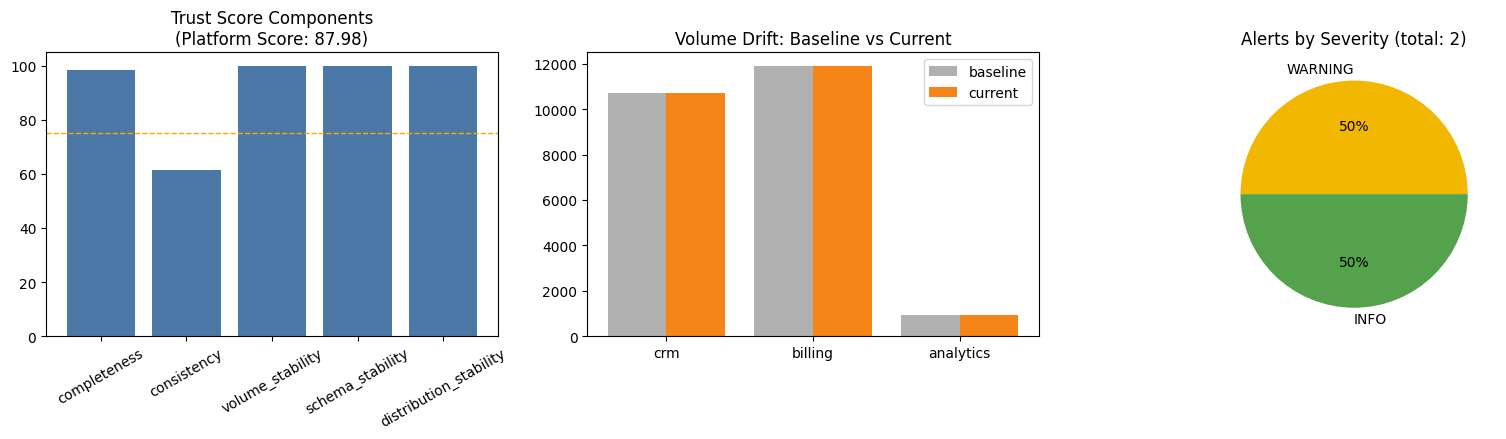

In [0]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Trust score components
comp_names = list(platform_components.keys())
comp_vals = [v if isinstance(v, (int, float)) else (100.0 if not v else 0.0) for v in platform_components.values()]
axes[0].bar(comp_names, comp_vals, color="#4C78A8")
axes[0].axhline(THRESHOLDS["trust_score_warn"], color="orange", linestyle="--", linewidth=1)
axes[0].set_title(f"Trust Score Components\n(Platform Score: {platform_trust_score})")
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis="x", rotation=30)

# Volume drift: baseline vs current per source
sources = [r["source"] for r in volume_drift_results]
base_counts = [r["baseline_count"] for r in volume_drift_results]
curr_counts = [r["current_count"] for r in volume_drift_results]
x = range(len(sources))
axes[1].bar([i - 0.2 for i in x], base_counts, width=0.4, label="baseline", color="#B0B0B0")
axes[1].bar([i + 0.2 for i in x], curr_counts, width=0.4, label="current", color="#F58518")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(sources)
axes[1].set_title("Volume Drift: Baseline vs Current")
axes[1].legend()

# Alert severity breakdown
sev_counts = {"CRITICAL": 0, "WARNING": 0, "INFO": 0}
for a in alerts:
    sev_counts[a["severity"]] += 1
colors = {"CRITICAL": "#E45756", "WARNING": "#F2B701", "INFO": "#54A24B"}
nonzero = {k: v for k, v in sev_counts.items() if v > 0}
if nonzero:
    axes[2].pie(nonzero.values(), labels=nonzero.keys(),
                 colors=[colors[k] for k in nonzero], autopct="%1.0f%%")
else:
    axes[2].text(0.5, 0.5, "No alerts", ha="center", va="center")
axes[2].set_title(f"Alerts by Severity (total: {len(alerts)})")

plt.tight_layout()
plt.show()
